In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("Customer_Churn.csv")
df

,Customer_ID,Age,Gender,Total_Purchases,Total_Spending,Membership_Status,Customer_Satisfaction,Support_Tickets,Last_Purchase_Days,Churn_Status
0,C1001,46,Male,36,66113,NaN,8,8,256,No
1,C1002,60,Male,11,179642,Silver,8,0,336,No
2,C1003,42,Male,27,75353,Gold,3,6,277,Yes
3,C1004,46,Male,30,119285,Silver,5,5,79,No
4,C1005,23,Male,9,129953,Silver,1,1,280,No
...,...,...,...,...,...,...,...,...,...,...
995,C1996,54,Male,40,60867,Silver,4,1,145,Yes
996,C1997,64,Female,37,79926,Silver,3,4,127,Yes
997,C1998,22,Male,24,95145,NaN,6,4,357,No
998,C1999,57,Male,14,123047,NaN,4,8,169,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Customer_ID            1000 non-null   object
 1   Age                    1000 non-null   int64 
 2   Gender                 1000 non-null   object
 3   Total_Purchases        1000 non-null   int64 
 4   Total_Spending         1000 non-null   int64 
 5   Membership_Status      649 non-null    object
 6   Customer_Satisfaction  1000 non-null   int64 
 7   Support_Tickets        1000 non-null   int64 
 8   Last_Purchase_Days     1000 non-null   int64 
 9   Churn_Status           1000 non-null   object
dtypes: int64(6), object(4)
memory usage: 78.3+ KB


In [4]:
df.head()

,Customer_ID,Age,Gender,Total_Purchases,Total_Spending,Membership_Status,Customer_Satisfaction,Support_Tickets,Last_Purchase_Days,Churn_Status
0,C1001,46,Male,36,66113,NaN,8,8,256,No
1,C1002,60,Male,11,179642,Silver,8,0,336,No
2,C1003,42,Male,27,75353,Gold,3,6,277,Yes
3,C1004,46,Male,30,119285,Silver,5,5,79,No
4,C1005,23,Male,9,129953,Silver,1,1,280,No


In [5]:
df.tail()

,Customer_ID,Age,Gender,Total_Purchases,Total_Spending,Membership_Status,Customer_Satisfaction,Support_Tickets,Last_Purchase_Days,Churn_Status
995,C1996,54,Male,40,60867,Silver,4,1,145,Yes
996,C1997,64,Female,37,79926,Silver,3,4,127,Yes
997,C1998,22,Male,24,95145,NaN,6,4,357,No
998,C1999,57,Male,14,123047,NaN,4,8,169,Yes
999,C2000,28,Female,47,41589,NaN,6,3,305,Yes


In [6]:
df.dtypes

Customer_ID              object
Age                       int64
Gender                   object
Total_Purchases           int64
Total_Spending            int64
Membership_Status        object
Customer_Satisfaction     int64
Support_Tickets           int64
Last_Purchase_Days        int64
Churn_Status             object
dtype: object

In [7]:
df.shape

(1000, 10)

In [8]:
df.isnull().sum()

Customer_ID                0
Age                        0
Gender                     0
Total_Purchases            0
Total_Spending             0
Membership_Status        351
Customer_Satisfaction      0
Support_Tickets            0
Last_Purchase_Days         0
Churn_Status               0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.describe()

,Age,Total_Purchases,Total_Spending,Customer_Satisfaction,Support_Tickets,Last_Purchase_Days
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.880000,25.681000,99814.429000,5.550000,5.116000,183.632000
std,15.449281,14.418777,56600.250529,2.885798,3.149041,104.323487
min,18.000000,1.000000,1866.000000,1.000000,0.000000,1.000000
25%,30.000000,13.000000,50437.250000,3.000000,2.000000,96.750000
50%,45.000000,26.000000,97446.000000,6.000000,5.000000,182.000000
75%,57.000000,38.000000,149882.500000,8.000000,8.000000,269.000000
max,70.000000,50.000000,199897.000000,10.000000,10.000000,365.000000


In [12]:
numeric_cols = ["Age", "Total_Purchases", "Total_Spending",
                "Customer_Satisfaction", "Support_Tickets", "Last_Purchase_Days"]
print("\nOutlier Summary")
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    count = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    print(f"{col} : {count} outliers")


Outlier Summary
Age : 0 outliers
Total_Purchases : 0 outliers
Total_Spending : 0 outliers
Customer_Satisfaction : 0 outliers
Support_Tickets : 0 outliers
Last_Purchase_Days : 0 outliers


In [13]:
print("\nData Validation")
print("Age valid (18-70)      :", df["Age"].between(18, 70).all())
print("Satisfaction valid (1-10):", df["Customer_Satisfaction"].between(1, 10).all())
print("Gender values          :", df["Gender"].unique())
print("Membership values      :", df["Membership_Status"].unique())
print("Churn values           :", df["Churn_Status"].unique())


Data Validation
Age valid (18-70)      : True
Satisfaction valid (1-10): True
Gender values          : ['Male' 'Female']
Membership values      : [nan 'Silver' 'Gold']
Churn values           : ['No' 'Yes']


# Problems

In [14]:
# Problem 1
total = len(df)
churned = (df['Churn_Status'] == 'Yes').sum()
retained = (df['Churn_Status'] == 'No').sum()
print("Total Customers:", total)
print("Churned (Yes):", churned)
print("Retained (No):", retained)
print("Churn Rate:", round((churned / total) * 100, 2), "%")

Total Customers: 1000
Churned (Yes): 557
Retained (No): 443
Churn Rate: 55.7 %


In [17]:
# Problem 2
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_churn = df.groupby(['Age_Group', 'Churn_Status']).size().unstack(fill_value=0)
age_churn['Churn_Rate_%'] = round((age_churn['Yes'] / (age_churn['Yes'] + age_churn['No'])) * 100, 2)
print(age_churn)

Churn_Status  No  Yes  Churn_Rate_%
Age_Group                          
<20           21   40         65.57
20-29         94   98         51.04
30-39         74  115         60.85
40-49         79   94         54.34
50-59         94  112         54.37
60+           81   98         54.75


C:\Users\kavya\AppData\Local\Temp\ipykernel_16472\494961497.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby(['Age_Group', 'Churn_Status']).size().unstack(fill_value=0)


In [20]:
# Problem 3
avg_spending = df.groupby('Churn_Status')['Total_Spending'].mean().round(2)
print("Average Spending:")
print(avg_spending)

Average Spending:
Churn_Status
No      98648.59
Yes    100741.66
Name: Total_Spending, dtype: float64


In [22]:
# Problem 4
mem_churn = df.groupby(['Membership_Status', 'Churn_Status']).size().unstack(fill_value=0)
mem_churn['Churn_Rate_%'] = round((mem_churn['Yes'] / (mem_churn['Yes'] + mem_churn['No'])) * 100, 2)
print(mem_churn)

Churn_Status        No  Yes  Churn_Rate_%
Membership_Status                        
Gold               164  169         50.75
Silver             160  156         49.37


In [28]:
#Problem 5
avg_sat = df.groupby('Churn_Status')['Customer_Satisfaction'].mean().round(2)
print("Average Satisfaction Score:")
print(avg_sat)

Average Satisfaction Score:
Churn_Status
No     6.51
Yes    4.79
Name: Customer_Satisfaction, dtype: float64


In [29]:
# Problem 6
avg_tickets = df.groupby('Churn_Status')['Support_Tickets'].mean().round(2)
print("Average Support Tickets:")
print(avg_tickets)

Average Support Tickets:
Churn_Status
No     4.35
Yes    5.73
Name: Support_Tickets, dtype: float64


In [33]:
# Problem 7
avg_purchases = df.groupby('Churn_Status')['Total_Purchases'].mean().round(2)
print("Average Number of Purchases:")
print(avg_purchases)

Average Number of Purchases:
Churn_Status
No     26.42
Yes    25.09
Name: Total_Purchases, dtype: float64


In [36]:
# Problem 8
high_risk = df[(df['Customer_Satisfaction'] <= 4) & (df['Support_Tickets'] >= 7) & (df['Total_Purchases'] <= 10)]
print("High-Risk Customers Found:", len(high_risk))
print(high_risk['Churn_Status'].value_counts())

High-Risk Customers Found: 26
Churn_Status
Yes    25
No      1
Name: count, dtype: int64


In [43]:
# Problem 9
df['Spending_Group'] = pd.cut(
    df['Total_Spending'], bins=[0, 60000, 130000, 200000], labels=['Low Spender', 'Medium Spender', 'High Spender'])
print(persona)

Churn_Status     No  Yes  Churn_Rate_%
Spending_Group                        
Low Spender     132  163         55.25
Medium Spender  161  199         55.28
High Spender    150  195         56.52


# Graphs

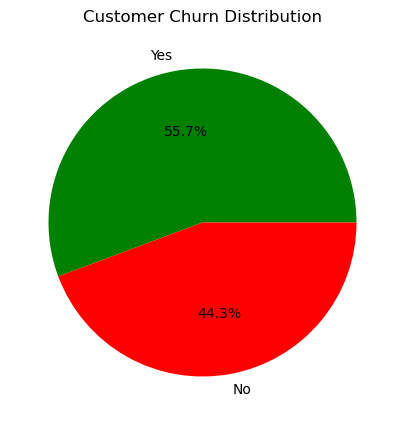

In [49]:
# Graph 1
churn_counts = df['Churn_Status'].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['green', 'red'])
plt.title('Customer Churn Distribution')
plt.show()

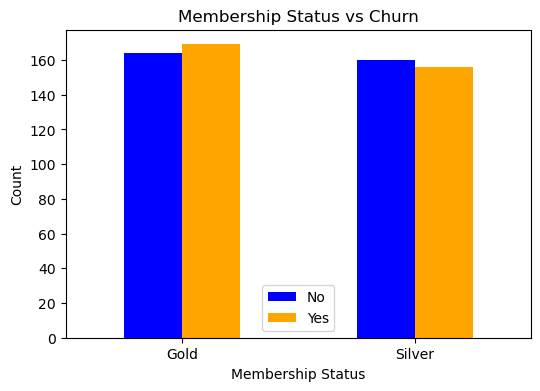

In [53]:
# Graph 2
mem_churn = df.groupby(['Membership_Status', 'Churn_Status']).size().unstack(fill_value=0)
mem_churn.plot(kind='bar', color=['blue', 'orange'], figsize=(6, 4))
plt.title('Membership Status vs Churn')
plt.xlabel('Membership Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
plt.show()

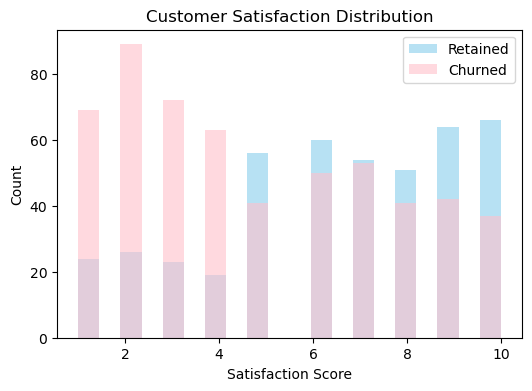

In [65]:
# Graph 3
plt.figure(figsize=(6, 4))
plt.hist(df[df['Churn_Status'] == 'No']['Customer_Satisfaction'], bins=20, color='skyblue', alpha=0.6, label='Retained')
plt.hist(df[df['Churn_Status'] == 'Yes']['Customer_Satisfaction'], bins=20, color='pink', alpha=0.6, label='Churned')
plt.title('Customer Satisfaction Distribution')
plt.xlabel('Satisfaction Score')
plt.ylabel('Count')
plt.legend()
plt.show()

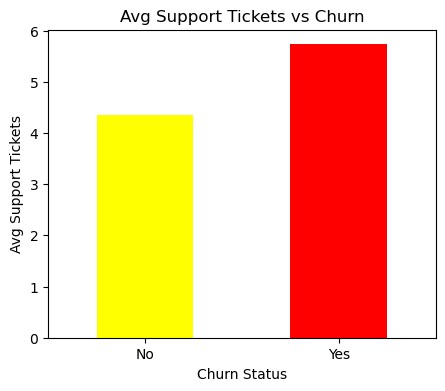

In [67]:
# Graph 4
avg_tickets = df.groupby('Churn_Status')['Support_Tickets'].mean()
plt.figure(figsize=(5, 4))
avg_tickets.plot(kind='bar', color=['yellow', 'red'])
plt.title('Avg Support Tickets vs Churn')
plt.xlabel('Churn Status')
plt.ylabel('Avg Support Tickets')
plt.xticks(rotation=0)
plt.show()

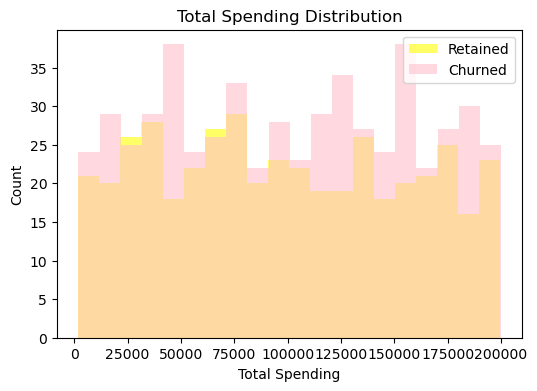

In [71]:
# Graph 5
plt.figure(figsize=(6, 4))
plt.hist(df[df['Churn_Status'] == 'No']['Total_Spending'], bins=20, color='yellow', alpha=0.6, label='Retained')
plt.hist(df[df['Churn_Status'] == 'Yes']['Total_Spending'], bins=20, color='pink', alpha=0.6, label='Churned')
plt.title('Total Spending Distribution')
plt.xlabel('Total Spending')
plt.ylabel('Count')
plt.legend()
plt.show()

C:\Users\kavya\AppData\Local\Temp\ipykernel_16472\1760078201.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn_Status', y='Total_Spending',palette={'Yes': 'green', 'No': 'red'})


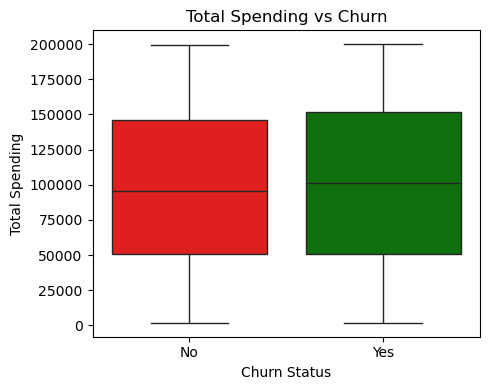

In [75]:
# Graph 6
plt.figure(figsize=(5, 4))
sns.boxplot(data=df, x='Churn_Status', y='Total_Spending',palette={'Yes': 'green', 'No': 'red'})
plt.title('Total Spending vs Churn')
plt.xlabel('Churn Status')
plt.ylabel('Total Spending')
plt.tight_layout()
plt.show()

C:\Users\kavya\AppData\Local\Temp\ipykernel_16472\75508728.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby(['Age_Group', 'Churn_Status']).size().unstack(fill_value=0)


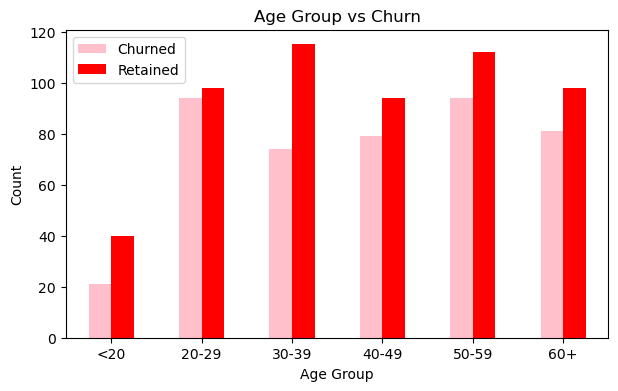

In [80]:
# Graph 7
age_churn = df.groupby(['Age_Group', 'Churn_Status']).size().unstack(fill_value=0)
age_churn.plot(kind='bar', color=['pink', 'red'], figsize=(7, 4))
plt.title('Age Group vs Churn')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Churned', 'Retained'])
plt.show()

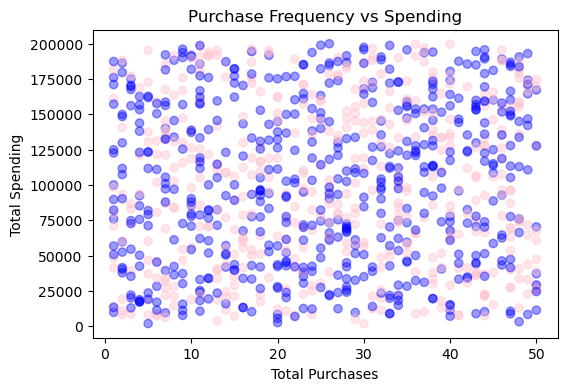

In [86]:
# Graph 8
colors = df['Churn_Status'].map({'Yes': 'blue', 'No': 'pink'})
plt.figure(figsize=(6, 4))
plt.scatter(df['Total_Purchases'], df['Total_Spending'], c=colors, alpha=0.4)
plt.title('Purchase Frequency vs Spending')
plt.xlabel('Total Purchases')
plt.ylabel('Total Spending')
plt.show()

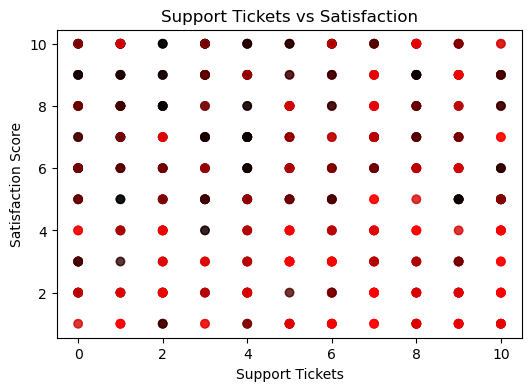

In [89]:
# Graph 9
colors = df['Churn_Status'].map({'Yes': 'red', 'No': 'black'})
plt.figure(figsize=(6, 4))
plt.scatter(df['Support_Tickets'], df['Customer_Satisfaction'], c=colors, alpha=0.4)
plt.title('Support Tickets vs Satisfaction')
plt.xlabel('Support Tickets')
plt.ylabel('Satisfaction Score')
plt.show()

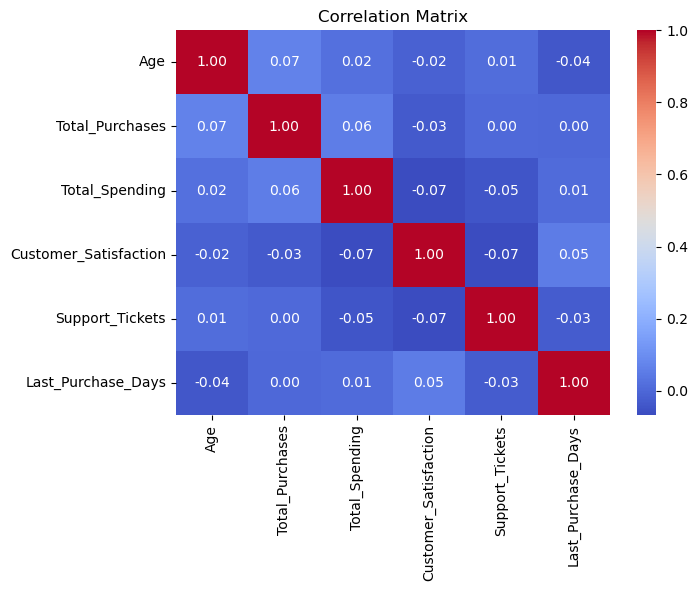

In [96]:
# Graph 10
num_cols = ['Age', 'Total_Purchases', 'Total_Spending',
            'Customer_Satisfaction', 'Support_Tickets', 'Last_Purchase_Days']
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()